# PID Portfolio Rebalancer

## Introduction
Proportional–Integral–Derivative (PID) controllers are used in a wide variety of functions across aerospace engineering. Just as an autopilot uses a PID controller to hold a target altitude, this project applies the concept to dynamically rebalance a portfolio, holding it at a target allocation. This is an analysis of the controller, including backtesting its performance compared to traditional "Buy and Hold" and "5% Threshold" strategies over the last 20 years on a sample portfolio.

## Mathematical Foundation

### Variable Definitions
For a portfolio with $N$ assets at time $t$, define:  
- $w_i^*(t)$: target weight for asset $i$  
- $w_i(t)$: actual weight of asset $i$  
- $e_i(t) = w_i^*(t) - w_i(t)$: error for asset $i$

### Proportional Term (P):  
$$u_i^P(t)=K_p \cdot e_i(t)$$  
Where $K_p$ is the proportional gain. This is the primary correction term, trading in direct proportion to today's drift.  

### Integral Term (I):  
$$u_i^I(t)=K_i \cdot \int_{0}^{t} e_i(\tau) d\tau$$  
In discrete time, this becomes:  
$$u_i^I(t)=K_i \cdot \sum_{\tau=0}^{t} e_i(\tau) \cdot \Delta t$$
Where $K_i$ is the integral gain. This term accumulates the past error, forcing a larger correction if an asset is persistently under or over weight.  

### Derivative Term (D):  
$$u_i^D(t) = K_d \cdot \frac{de_i}{dt}$$
In discrete time, this becomes:  
$$u_i^D(t) = K_d \cdot \frac{e_i(t)-e_i(t-1)}{\Delta t}$$
Where $K_d$ is the derivative gain. This term accounts for the rate of change of the error to avoid overcorrecting.  

### The Full Control Signal:  
Thus, the total for asset $i$ at time $t$ is:  
$$u_i(t) = K_p \cdot e_i(t) + K_i \cdot \sum_{\tau=0}^{t} e_i(\tau) \cdot \Delta t + K_d \cdot \frac{e_i(t)-e_i(t-1)}{\Delta t}$$  
$u_i(t)$ is a signed trade size, where positive means buy and negative means sell.  

| Gain | Too High | Too Low |
|------|----------|---------|
| $K_p$ | Overtrading on noise | Slow response to drift |
| $K_i$ | Integrator windup | Ignores persistent drift |
| $K_d$ | Reacts to every daily fluctuation | No dampening, can overshoot |

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from backtest import run_backtest, run_buy_and_hold, run_threshold
from data_pipeline import get_prices

# Parameters
tickers = ['SPY', 'EFA', 'TLT', 'TIP', 'GLD', 'VNQ']
target_weight = np.array([0.25, 0.15, 0.20, 0.15, 0.15, 0.10])
start = "2006-01-01"
end = "2026-01-01"
Kp = 0.5
Ki = 0.01
Kd = 0.1
minintegral = -1.0
maxintegral = 1.0
dt = 1
transaction_cost = 0.001
threshold = 0.05
close = get_prices(tickers, start, end)
returns = close.pct_change()

# Run all three strategies
pid_u, pid_dates, pid_values, pid_weights = run_backtest(target_weight, Kp, Ki, Kd, minintegral, maxintegral, dt, transaction_cost, returns)
bah_dates, bah_values, bah_weights = run_buy_and_hold(start, end, tickers, target_weight)
thr_u, thr_dates, thr_values, thr_weights = run_threshold(target_weight, transaction_cost, start, end, tickers, threshold)

## Portfolio Setup
The sample portfolio is made up of the following six securities:
- SPY (S&P 500): 25%
- EFA (International Developed Markets Equities): 15%
- TLT (20+ Year Treasury Bond): 20%
- TIP (Treasury Inflation-Protected Bonds): 15%
- GLD (Gold): 15%
- VNQ (Real Estate): 10%

A diversified, multi-asset portfolio was chosen as these asset classes move differently from each other, ensuring genuine drift occurs between asset classes, which is where rebalancing strategies add the most value. The overall backtest runs from 2006-01-01 to 2026-01-01, covering a variety of market regimes including the 2008 financial crisis, COVID-19, a rate hike cycle, and a bull market.

## Equity Curve Analysis
Below, the PID strategy is compared to two other strategies:
- Buy and Hold: Each security is held at without rebalancing or trading at all
- 5% Threshold: Each security is rebalanced when they stray from their corresponding target weight by over 5%

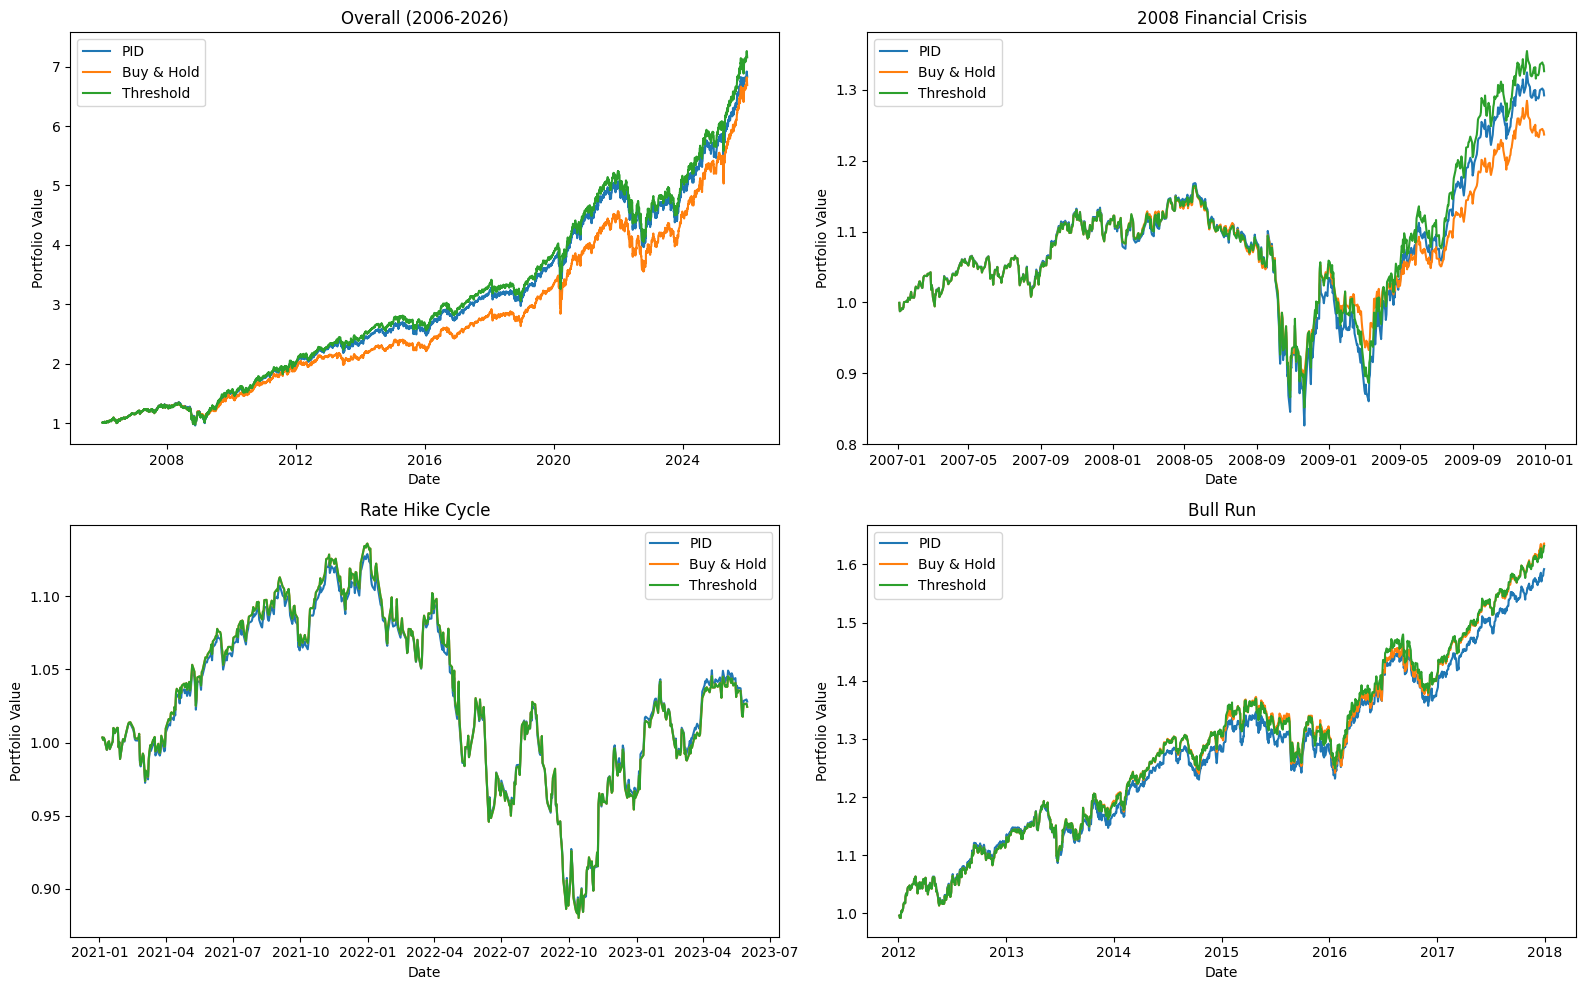

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

regimes = [
    ("Overall (2006-2026)", "2006-01-01", "2026-01-01"),
    ("2008 Financial Crisis", "2007-01-01", "2010-01-01"),
    ("Rate Hike Cycle", "2021-01-01", "2023-06-01"),
    ("Bull Run", "2012-01-01", "2018-01-01"),
]

for (title, start, end), ax in zip(regimes, axes.flatten()):
    close = get_prices(tickers, start, end)
    returns_plot = close.pct_change()
    pid_u_plot, pid_dates_plot, pid_values_plot, pid_weights_plot = run_backtest(target_weight, Kp, Ki, Kd, minintegral, maxintegral, dt, transaction_cost, returns_plot)
    bah_dates_plot, bah_values_plot, bah_weights_plot = run_buy_and_hold(start, end, tickers, target_weight)
    thr_u_plot, thr_dates_plot, thr_values_plot, thr_weights_plot = run_threshold(target_weight, transaction_cost, start, end, tickers, threshold)
    ax.plot(pid_dates_plot, pid_values_plot, label='PID')
    ax.plot(bah_dates_plot, bah_values_plot, label='Buy & Hold')
    ax.plot(thr_dates_plot, thr_values_plot, label='Threshold')
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Portfolio Value')
    ax.legend()

plt.tight_layout()
plt.savefig('images/equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 2008 Financial Crisis
Each strategy behaved similarly during the buildup through the market crash, bottoming out in late 2008. As both the PID and threshold strategies continuously rebalanced during the dip, they were poised for a stronger recovery as equities grew sharply.
### Rate Hike Cycle
Each strategy performs nearly identically throughout the rate hike cycle. When bonds and equities fall simultaneously, diversification breaks down and no rebalancing strategy can add value because there's nothing to rebalance into.
### Bull Run
In the bull run, the PID strategy was penalised by continous rebalancing, leading to lower performance. The more a strategy rebalances, the more transaction fees are paid, hedging its growth.
### Overall
Over the 20 year span, both the PID and threshold strategies outperformed simply buying and holding. This shows that rebalancing works in the long run, despite transaction fees.

In conclusion, buying and holding stays the leader in straight bull markets, when the downside of rebalancing is amplified. However, in periods after a crash, and in the long run, rebalancing strategies like PID and threshold work.

## Statistical Analysis
The table below shows the Sharpe ratios, maximum drawdown, and annual turnover for each of the three strategies over the same 20 year span, computed using default gain values.

In [3]:
def sharpe(values):
    values = np.array(values)
    returns_daily = (values[1:] - values[:-1]) / values[:-1]
    sharpe = np.mean(returns_daily) / np.std(returns_daily) * np.sqrt(252)
    return(sharpe)
    
def max_drawdown(values):
    values = np.array(values)
    max_value = np.maximum.accumulate(values)
    MDD = np.min((values - max_value) / max_value)
    return(MDD)

def annual_turnover(u_values):
    u = np.array(u_values)
    AT = np.mean(np.sum(np.abs(u), axis=1)) * 252
    return(AT)
    
print(f"{'Strategy':<20} {'Sharpe':>8} {'Max DD':>8} {'Turnover':>10}")
print("-" * 50)
print(f"{'PID':<20} {sharpe(pid_values):>8.3f} {max_drawdown(pid_values):>8.3f} {annual_turnover(pid_u):>10.3f}")
print(f"{'Threshold':<20} {sharpe(thr_values):>8.3f} {max_drawdown(thr_values):>8.3f} {annual_turnover(thr_u):>10.3f}")
print(f"{'Buy and Hold':<20} {sharpe(bah_values):>8.3f} {max_drawdown(bah_values):>8.3f} {'N/A':>10}")

Strategy               Sharpe   Max DD   Turnover
--------------------------------------------------
PID                     0.880   -0.293      0.965
Threshold               0.902   -0.278      0.062
Buy and Hold            0.926   -0.264        N/A


Using the default gains, the PID strategy underperforms the others in all three categories. Notably, the PID has an annual turnover of over 96%, signalling significant overtrading. This is expected with untuned gains, and will improve with sensitivity analysis. The buy and hold strategy has the best Sharpe ratio and maximum drawdown, while the threshold strategy has a decent Sharpe ratio, but a very low turnover.

## Sensitivity Analysis
Thus far, our results have been computed using $K_p = 0.5$, $K_i = 0.01$, and $K_d = 0.1$. However, these gains can be tuned to improve Sharpe ratio and annual turnover using a grid of gain values.

In [4]:
Kp_grid = np.linspace(0.1, 1.0, 20)
Ki_grid = np.linspace(0.001, 0.05, 20)
sharpe_map = np.zeros((20, 20))
turnover_map = np.zeros((20, 20))

for i, Kp in enumerate(Kp_grid):
    for j, Ki in enumerate(Ki_grid):
        pid_u_heat, pid_dates_heat, pid_values_heat, pid_weights_heat = run_backtest(target_weight, Kp, Ki, Kd, minintegral, maxintegral, dt, transaction_cost, returns)
        sharpe_map[i,j] = sharpe(pid_values_heat)
        turnover_map[i,j] = annual_turnover(pid_u_heat)

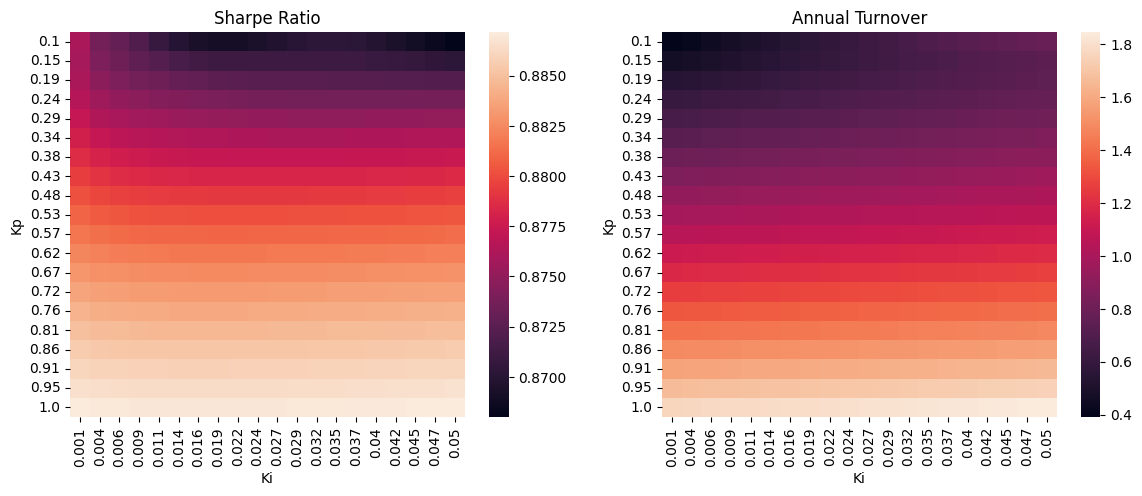

In [5]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(sharpe_map, ax=ax1, 
            xticklabels=np.round(Ki_grid, 3), 
            yticklabels=np.round(Kp_grid, 2))
ax1.set_title('Sharpe Ratio')
ax1.set_xlabel('Ki')
ax1.set_ylabel('Kp')

sns.heatmap(turnover_map, ax=ax2, 
            xticklabels=np.round(Ki_grid, 3), 
            yticklabels=np.round(Kp_grid, 2))
ax2.set_title('Annual Turnover')
ax2.set_xlabel('Ki')
ax2.set_ylabel('Kp')
plt.savefig('images/sharpe_turnover_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

From the heatmaps, there is negligible variation in Sharpe ratio as it only ranges from 0.870 to 0.885. Therefore we can optimise for a lower annual turnover to minimise transaction costs and improve net returns. A $K_i$ of 0.001 and $K_p$ of 0.1 returns a reasonable annual turnover of 40%, much lower than the 96% observed with the default $K_p$. Also, $K_i$ has a low impact on turnover as seen from the horizontal lines on the annual turnover heatmap, so $K_p$ is the primary tuning lever.

## Weight Drift Analysis
The whole point of the PID controller is to accurately maintain our target portfolio weights. Below, the PID strategy is once again compared to the other strategies in terms of how much its weights drift over time. Plotting two sets, one with $K_p = 0.1$ and one with $K_p = 1.0$ will also demonstrate how $K_p$ affects the PID strategy's accuracy.
$$\text{drift}(t)=\frac{1}{N}\sum_{i=1}^{N}|w_i(t)-w_i^*(t)|$$

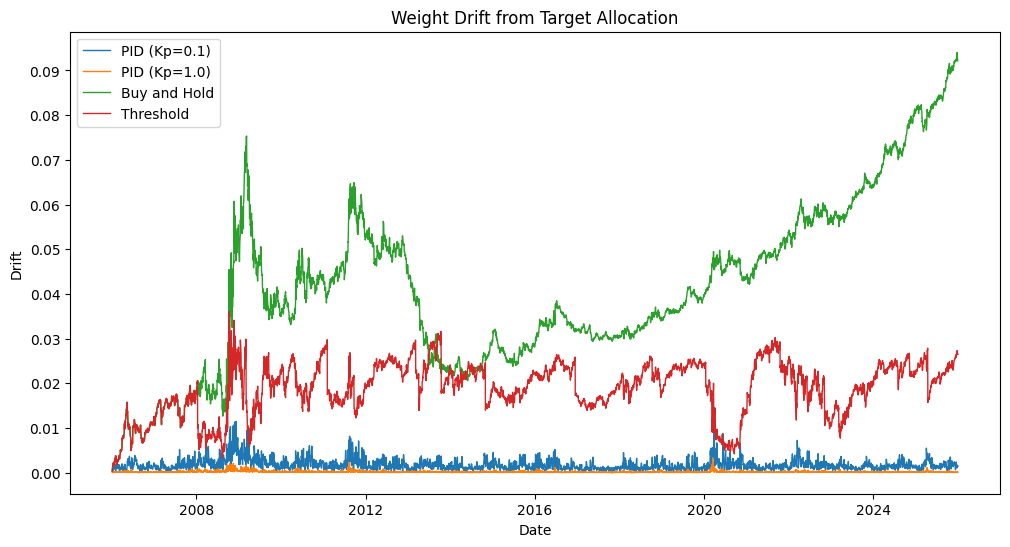

In [8]:
def compute_drift(weights, target_weight):
    weights_array = np.array(weights)
    drift = np.mean(np.abs(weights_array - target_weight), axis=1)
    return drift

_, _, _, pid_weights_low = run_backtest(target_weight, 0.1, Ki, Kd, minintegral, maxintegral, dt, transaction_cost, returns)
_, _, _, pid_weights_high = run_backtest(target_weight, 1.0, Ki, Kd, minintegral, maxintegral, dt, transaction_cost, returns)

plt.figure(figsize=(12, 6))
plt.plot(pid_dates, compute_drift(pid_weights_low, target_weight), label='PID (Kp=0.1)', linewidth=1)
plt.plot(pid_dates, compute_drift(pid_weights_high, target_weight), label='PID (Kp=1.0)', linewidth=1)
plt.plot(bah_dates, compute_drift(bah_weights, target_weight), label='Buy and Hold', linewidth=1)
plt.plot(thr_dates, compute_drift(thr_weights, target_weight), label='Threshold', linewidth=1)
plt.title('Weight Drift from Target Allocation')
plt.xlabel('Date')
plt.ylabel('Drift')
plt.legend()
plt.yticks(np.arange(0, 0.10, 0.01))
plt.savefig('images/weight_drift.png', dpi=150, bbox_inches='tight')
plt.show()


According to the plot, the buy and hold strategy drifts up to 9%, which is expected given that it does not rebalance at all. The threshold strategy is able to keep the drift within 1%-3% for the most part. However, both PID strategies keep the drift to a minimal level. Even with large market swings in 2008 and 2020, the PID kept the portfolio to a <1% drift, resulting in ~20x more accuracy than the buy and hold strategy and ~5-10x more accuracy than the threshold strategy. At $K_p=1.0$ the PID controller is the most accurate, with the tradoff of a worse annual turnover as established.

## Project Conclusion
### Purpose
This project aimed to build and analyze a PID controller to dynamically rebalance a portfolio, maintaining a target allocation of each asset.
### Key Findings
Backtesting over the last 20 years, the following conclusions are drawn:
1. The PID strategy had significantly less weight drift than the other two strategies, having ~20x more accuracy than the buy and hold strategy and ~5-10x more accuracy than the threshold strategy.
2. Both rebalancing strategies (PID and threshold) outperform buy and hold in market dips. However, in bull markets, buy and hold is stronger due to the lack of transaction costs. Each of the three strategies' returns were nearly identical in sideways markets.
3. Statistically, the PID strategy had a lower Sharpe ratio than the other two strategies, with a similar maximum drawdown. It also has a relatively high annual turnover of 40% at a low $K_p$ to 96% at a high $K_p$.
4. The PID strategy's Sharpe Ratio is roughly constant across $K_p$ and $K_i$ values. Its annual turnover is largely dependent on its $K_p$ with changes in $K_i$ being negligible.
### Project Limitations:
This project holds the following assumptions and limitations:
- The backtest did not account for taxes in any way
- The backtest did not account for slippage in any way
- The backtest assumed instant, fractional orders
- The backtest used manually selected, unoptimised target weights
### What's Next
The next part of this project will be replacing the relatively arbitrary static weights with dynamically optimised allocations utilizing Markowitz Portfolio Theory.